In [95]:
import pandas as pd

In [96]:
df = pd.read_csv("TITAN.csv")
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,TITAN,EQ,144.95,146.0,156.45,146.0,155.00,155.70,154.36,23000,3.550370e+11,NaN,NaN,NaN
1,2000-01-04,TITAN,EQ,155.70,152.0,152.00,144.0,148.05,147.40,146.72,26300,3.858700e+11,NaN,NaN,NaN
2,2000-01-05,TITAN,EQ,147.40,144.0,148.80,136.0,139.95,138.40,142.95,20600,2.944850e+11,NaN,NaN,NaN
3,2000-01-06,TITAN,EQ,138.40,142.0,149.50,141.0,149.50,149.50,147.87,31600,4.672750e+11,NaN,NaN,NaN
4,2000-01-07,TITAN,EQ,149.50,149.5,153.00,145.0,147.75,146.35,148.63,36600,5.439965e+11,NaN,NaN,NaN


In [97]:
df.shape

(5306, 15)

In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   str    
 1   Symbol              5306 non-null   str    
 2   Series              5306 non-null   str    
 3   Prev Close          5306 non-null   float64
 4   Open                5306 non-null   float64
 5   High                5306 non-null   float64
 6   Low                 5306 non-null   float64
 7   Last                5306 non-null   float64
 8   Close               5306 non-null   float64
 9   VWAP                5306 non-null   float64
 10  Volume              5306 non-null   int64  
 11  Turnover            5306 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  4792 non-null   float64
 14  %Deliverble         4792 non-null   float64
dtypes: float64(11), int64(1), str(3)
memory usage: 621.9 KB


In [99]:
df["Date"] = pd.to_datetime(df["Date"].astype(str), errors="coerce")

In [100]:
df = df.sort_values("Date").reset_index(drop=True)

In [101]:
numeric_df =df.iloc[:, 3:-1]

In [102]:
numeric_df.shape

(5306, 11)

In [103]:
numeric_df.head()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
0,144.95,146.0,156.45,146.0,155.00,155.70,154.36,23000,3.550370e+11,NaN,NaN
1,155.70,152.0,152.00,144.0,148.05,147.40,146.72,26300,3.858700e+11,NaN,NaN
2,147.40,144.0,148.80,136.0,139.95,138.40,142.95,20600,2.944850e+11,NaN,NaN
3,138.40,142.0,149.50,141.0,149.50,149.50,147.87,31600,4.672750e+11,NaN,NaN
4,149.50,149.5,153.00,145.0,147.75,146.35,148.63,36600,5.439965e+11,NaN,NaN


In [104]:
numeric_df.isna().sum()

Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     514
dtype: int64

In [105]:
numeric_df = numeric_df.interpolate(method="linear", limit_direction="both")

In [106]:
numeric_df = numeric_df.ffill().bfill()

In [107]:
numeric_df.isnull().sum()

Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
dtype: int64

In [108]:
numeric_df.duplicated().sum()

np.int64(0)

In [109]:
feature_names = numeric_df.columns.tolist()
num_features = df.shape[1]

In [110]:
print("Features used:", feature_names)

Features used: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']


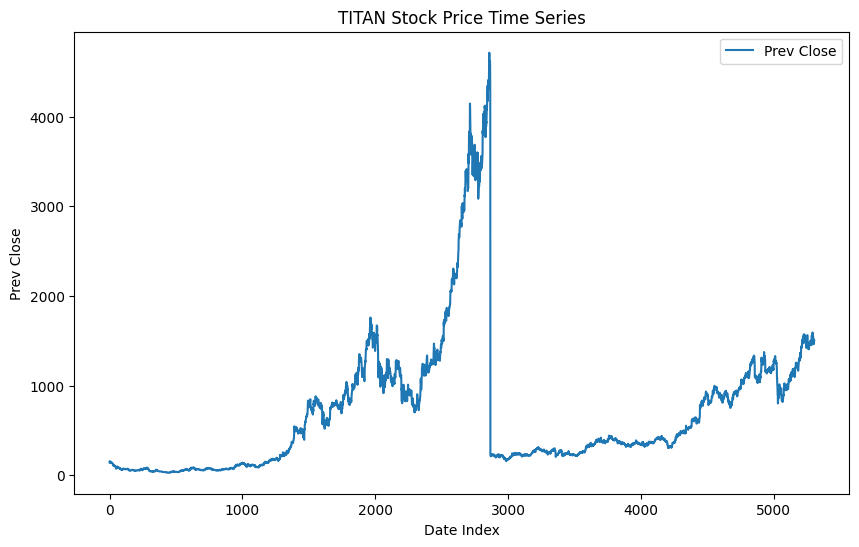

In [111]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(numeric_df.index, numeric_df[feature_names[0]], label = feature_names[0])

plt.title('TITAN Stock Price Time Series')
plt.xlabel('Date Index')
plt.ylabel(feature_names[0])
plt.legend()
plt.show()

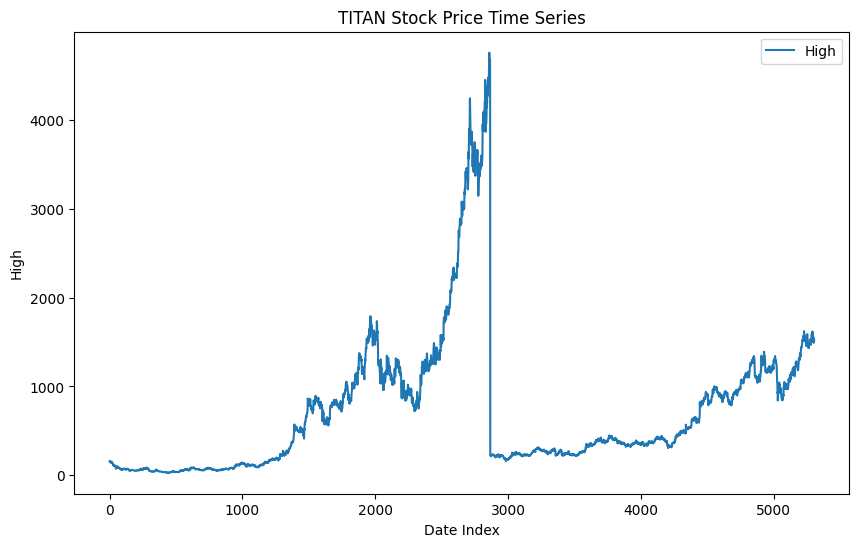

In [112]:
plt.figure(figsize=(10, 6))
plt.plot(numeric_df.index, numeric_df[feature_names[2]], label=feature_names[2])

plt.title('TITAN Stock Price Time Series')
plt.xlabel('Date Index')
plt.ylabel(feature_names[2])
plt.legend()
plt.show()

In [113]:
import numpy as np
data = numeric_df.values.astype(np.float32)
print("Data shape:", data.shape)

Data shape: (5306, 11)


In [114]:
data

array([[1.4495000e+02, 1.4600000e+02, 1.5645000e+02, ..., 3.5503699e+11,
        2.7244000e+04, 1.2939000e+04],
       [1.5570000e+02, 1.5200000e+02, 1.5200000e+02, ..., 3.8587000e+11,
        2.7244000e+04, 1.2939000e+04],
       [1.4739999e+02, 1.4400000e+02, 1.4880000e+02, ..., 2.9448500e+11,
        2.7244000e+04, 1.2939000e+04],
       ...,
       [1.4951000e+03, 1.5050000e+03, 1.5149000e+03, ..., 1.5615645e+14,
        3.7985000e+04, 2.1209800e+05],
       [1.5088500e+03, 1.5240000e+03, 1.5275000e+03, ..., 2.9111812e+14,
        6.3568000e+04, 4.9214400e+05],
       [1.5068000e+03, 1.5000000e+03, 1.5165500e+03, ..., 5.5122006e+14,
        1.1198600e+05, 6.9958600e+05]], shape=(5306, 11), dtype=float32)

In [115]:
INPUT_STEPS = 10
OUTPUT_STEPS = 5
TRAIN_RATIO = 0.8
BATCH_SIZE = 4

In [116]:
split_idx = int(len(data) * TRAIN_RATIO)
train_data1 = data[:split_idx]
test_data = data[split_idx:]

val_split_idx = int(len(train_data1) * 0.8)
train_data = train_data1[:val_split_idx]
val_data = train_data1[val_split_idx:]

In [117]:
train_data.shape, test_data.shape, val_data.shape

((3395, 11), (1062, 11), (849, 11))

In [118]:
from sklearn.preprocessing import normalize
train_data_norm = normalize(train_data, norm='l2', axis=0)
test_data_norm = normalize(test_data, norm='l2', axis=0)
val_data_norm = normalize(val_data, norm='l2', axis=0)

In [119]:
def create_sequences(data_array, input_steps=10, output_steps=5, overlap=1):
    X, y = [], []
    total_len = len(data_array)

    stride = input_steps - overlap
    if stride <=0 :
        raise ValueError("Overlap must be smaller than input steps")

    for i in range(0, total_len - input_steps - output_steps + 1, stride):
        X.append(data_array[i:i + input_steps])
        y.append(data_array[i + input_steps: i + input_steps + output_steps])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [120]:
X_train, y_train = create_sequences(train_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_test, y_test = create_sequences(test_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_val, y_val = create_sequences(val_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)


print("X_train: ", X_train.shape, "y_train: ", y_train.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)
print("X_val: ", X_val.shape, "y_val: ", y_val.shape)

X_train:  (1691, 10, 11) y_train:  (1691, 5, 11)
X_test:  (524, 10, 11) y_test:  (524, 5, 11)
X_val:  (418, 10, 11) y_val:  (418, 5, 11)


In [121]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [122]:
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)
val_dataset = TimeSeriesDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [123]:
import torch.nn as nn
class LSTMForecaster(nn.Module):
    def __init__(self):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(11, 10, batch_first=True)
        self.fc = nn.Linear(10, 5 * 11)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.view(-1, 5, 11)

In [124]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [125]:
model = LSTMForecaster().to(device)
lr = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

In [126]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

In [127]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)

            loss = criterion(preds, y_batch)
            running_loss += loss.item() * X_batch.size(0)

            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

In [128]:
EPOCHS = 100
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _= evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch [1/100] | Train Loss: 0.021839 | Val Loss: 0.011863
Epoch [2/100] | Train Loss: 0.006405 | Val Loss: 0.003051
Epoch [3/100] | Train Loss: 0.001047 | Val Loss: 0.000916
Epoch [4/100] | Train Loss: 0.000235 | Val Loss: 0.000680
Epoch [5/100] | Train Loss: 0.000184 | Val Loss: 0.000606
Epoch [6/100] | Train Loss: 0.000177 | Val Loss: 0.000627
Epoch [7/100] | Train Loss: 0.000174 | Val Loss: 0.000587
Epoch [8/100] | Train Loss: 0.000170 | Val Loss: 0.000587
Epoch [9/100] | Train Loss: 0.000167 | Val Loss: 0.000572
Epoch [10/100] | Train Loss: 0.000164 | Val Loss: 0.000555
Epoch [11/100] | Train Loss: 0.000159 | Val Loss: 0.000565
Epoch [12/100] | Train Loss: 0.000154 | Val Loss: 0.000564
Epoch [13/100] | Train Loss: 0.000147 | Val Loss: 0.000543
Epoch [14/100] | Train Loss: 0.000138 | Val Loss: 0.000474
Epoch [15/100] | Train Loss: 0.000127 | Val Loss: 0.000453
Epoch [16/100] | Train Loss: 0.000116 | Val Loss: 0.000443
Epoch [17/100] | Train Loss: 0.000106 | Val Loss: 0.000414
Epoch 

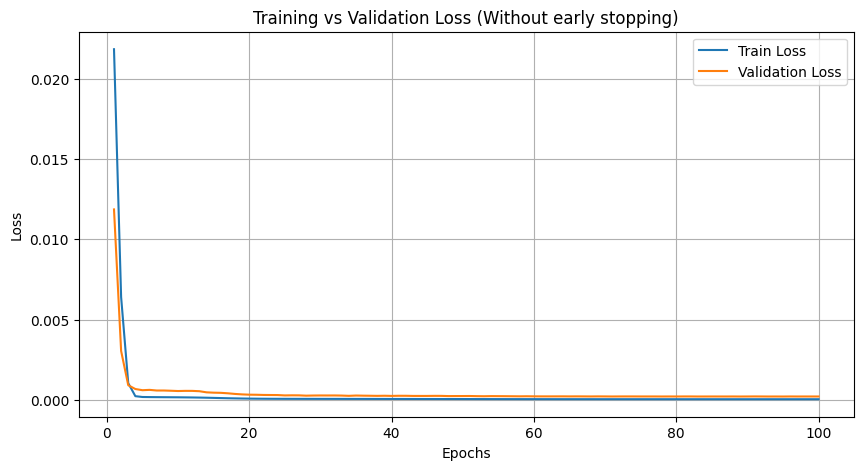

In [129]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Without early stopping)")
plt.legend()
plt.grid(True)

plt.show()

In [130]:
model = LSTMForecaster().to(device)
lr=0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

In [131]:
EPOCHS = 100
PATIENCE = 10
train_losses = []
val_losses = []
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _= evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss :.6f} | Val Loss: {val_loss :.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break


Epoch [1/100] | Train Loss: 0.023787 | Val Loss: 0.013407
Epoch [2/100] | Train Loss: 0.006360 | Val Loss: 0.002492
Epoch [3/100] | Train Loss: 0.000828 | Val Loss: 0.000762
Epoch [4/100] | Train Loss: 0.000221 | Val Loss: 0.000642
Epoch [5/100] | Train Loss: 0.000190 | Val Loss: 0.000669
Epoch [6/100] | Train Loss: 0.000188 | Val Loss: 0.000634
Epoch [7/100] | Train Loss: 0.000187 | Val Loss: 0.000655
Epoch [8/100] | Train Loss: 0.000185 | Val Loss: 0.000613
Epoch [9/100] | Train Loss: 0.000184 | Val Loss: 0.000615
Epoch [10/100] | Train Loss: 0.000183 | Val Loss: 0.000631
Epoch [11/100] | Train Loss: 0.000182 | Val Loss: 0.000646
Epoch [12/100] | Train Loss: 0.000180 | Val Loss: 0.000643
Epoch [13/100] | Train Loss: 0.000179 | Val Loss: 0.000629
Epoch [14/100] | Train Loss: 0.000177 | Val Loss: 0.000626
Epoch [15/100] | Train Loss: 0.000176 | Val Loss: 0.000604
Epoch [16/100] | Train Loss: 0.000174 | Val Loss: 0.000584
Epoch [17/100] | Train Loss: 0.000172 | Val Loss: 0.000534
Epoch 

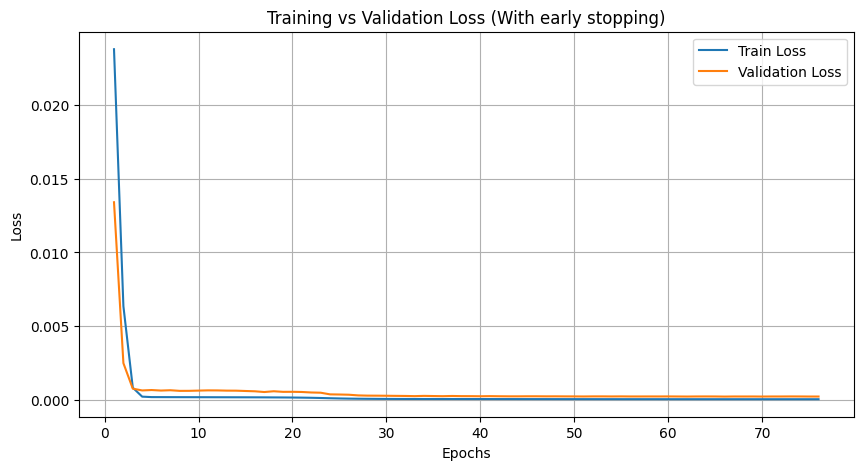

In [132]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (With early stopping)")
plt.legend()
plt.grid(True)

plt.show()

In [133]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [134]:
test_loss, predictions, targets = evaluate(model, test_loader, criterion, device)
print("Test Loss: ", test_loss )

Test Loss:  0.00013532341622417786


In [135]:
predictions.shape, targets.shape

((524, 5, 11), (524, 5, 11))

In [136]:
predictions

array([[[0.01075573, 0.00942347, 0.01075754, ..., 0.01545644,
         0.01506639, 0.0129558 ],
        [0.01050135, 0.01372084, 0.01193053, ..., 0.01239014,
         0.01842568, 0.0117413 ],
        [0.01062028, 0.01115525, 0.01099533, ..., 0.01539422,
         0.01946184, 0.01685829],
        [0.01226431, 0.01286864, 0.01268934, ..., 0.01302941,
         0.01693903, 0.00938018],
        [0.01211974, 0.01058269, 0.01178646, ..., 0.01170881,
         0.0171287 , 0.01224831]],

       [[0.01104722, 0.00994527, 0.01145191, ..., 0.01298003,
         0.0143625 , 0.01071255],
        [0.01014578, 0.01438312, 0.01284341, ..., 0.01108923,
         0.0174678 , 0.0102335 ],
        [0.01174457, 0.01169449, 0.01209009, ..., 0.0143603 ,
         0.01882353, 0.01396461],
        [0.01283351, 0.01322839, 0.01252423, ..., 0.01171499,
         0.01664691, 0.00770205],
        [0.01295303, 0.01081531, 0.0124736 , ..., 0.01067193,
         0.01686098, 0.01033706]],

       [[0.01068583, 0.01016796, 0.0

In [137]:
preds_2d = predictions.reshape(-1, predictions.shape[-1])
targets_2d = targets.reshape(-1, targets.shape[-1])
preds_2d.shape, targets_2d.shape

((2620, 11), (2620, 11))

In [138]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(targets_2d, preds_2d)
rmse = np.sqrt(mse)
mae = mean_absolute_error(targets_2d, preds_2d)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.00013532335287891328
RMSE: 0.011632856608714529
MAE: 0.005241683684289455


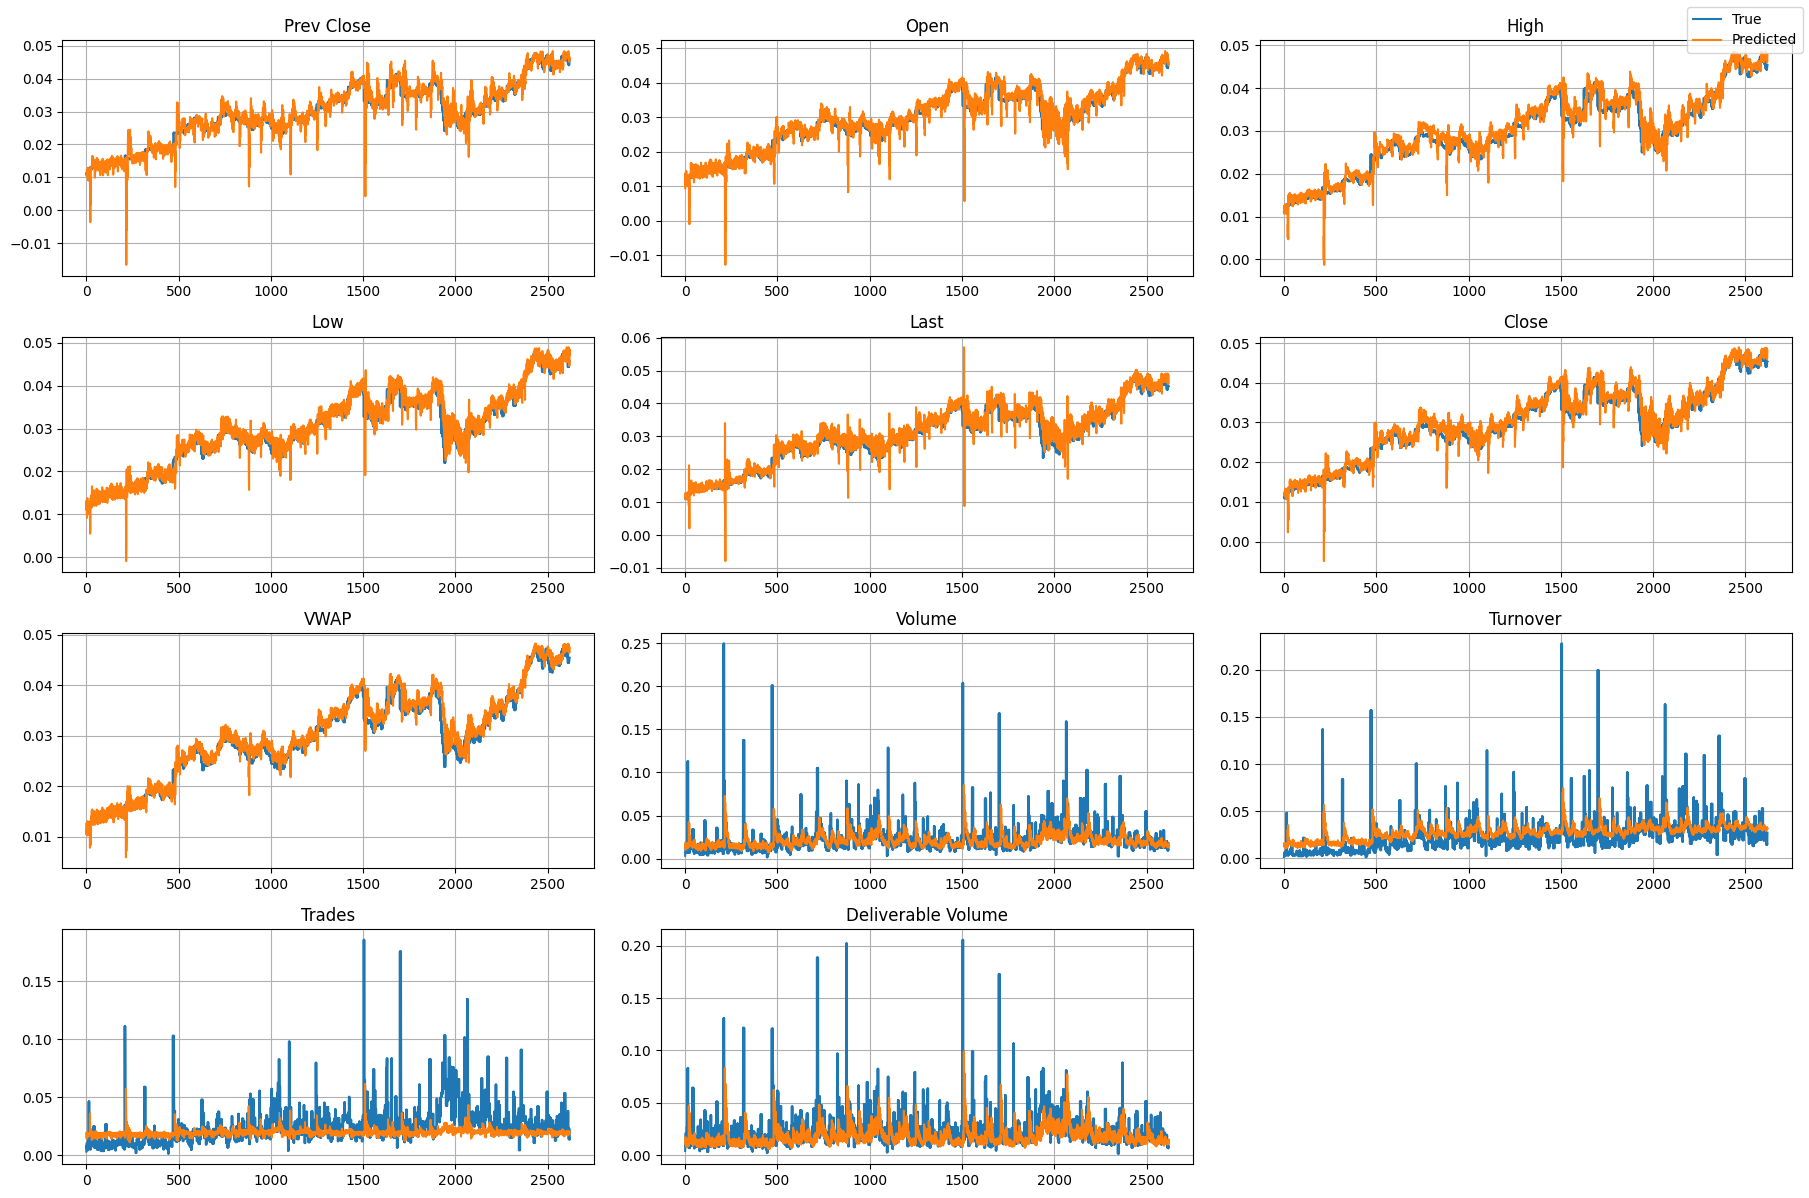

In [139]:
import matplotlib.pyplot as plt

num_features = predictions.shape[-1]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i in range(num_features):
    pred_feature = predictions[:, :, i].reshape(-1)
    true_feature = targets[:, :, i].reshape(-1)

    axes[i].plot(true_feature, label="True")
    axes[i].plot(pred_feature, label="Predicted")
    axes[i].set_title(feature_names[i])
    axes[i].grid(True)

fig.delaxes(axes[-1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()